In [57]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append('../src')
from pre_processing import df_transform_experimental, prepare_for_training
import os
os.environ["WANDB_SILENT"] = "true"
import wandb
import pandas as pd

DATA_PATH = '../data/train.csv'
CLASS_NAMES = ["Clutter", "Cormorants", "Pigeons", "Ducks", "Geese", "Gulls", "Birds of Prey", "Waders", "Songbirds"]

from feature_config import features_config

df = pd.read_csv(DATA_PATH)
transformed = df_transform_experimental(df, features_config, True)
X, y, features = prepare_for_training(transformed, features_config)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
from training import run_cv_training_xgboost
from custom_scoring import calculate_macro_ap

params = {
            'n_estimators': 1000,
            'learning_rate': 0.05,
            'max_depth': 6,
            'objective': 'multi:softprob',
            'num_class': len(CLASS_NAMES),
            'tree_method': 'hist',
            'early_stopping_rounds': 100,
            'random_state': 42,
            'use_weights': False
        }

config = {
    'params':params,
    'feature_version':features,
}

wandb.init(project="AICup", config=config)
models, oof_preds= run_cv_training_xgboost(X, y, class_names=CLASS_NAMES, params=params)
#models, oof_preds= run_cv_training_cat(X, y, class_names=CLASS_NAMES)
final_score, detailed_scores = calculate_macro_ap(y, oof_preds, CLASS_NAMES)
wandb.log({"mean_macro_ap": final_score})
wandb.log({"detailed_scores": detailed_scores})
wandb.finish()

print(final_score)


from result_analysis import debug_per_class_scores

debug_per_class_scores(y, oof_preds)

Fold 1 | Best Iter: 450 | Score: 0.5950
Fold 2 | Best Iter: 370 | Score: 0.5756
Fold 3 | Best Iter: 348 | Score: 0.6346
Fold 4 | Best Iter: 332 | Score: 0.6250
Fold 5 | Best Iter: 375 | Score: 0.5831
0.5831782681000752

--- Per-Class Performance ---


,Class,AP_Score,Support
0,Clutter,0.917795,84
2,Pigeons,0.847967,122
5,Gulls,0.836100,1503
8,Songbirds,0.622506,483
4,Geese,0.551571,83
3,Ducks,0.532038,58
6,Birds of Prey,0.450446,108
7,Waders,0.399458,120
1,Cormorants,0.090724,40


In [59]:
from kaggle_prediction import generate_ensemble_submission

#generate_submission(model, features_config)
#(models, features_config)

Generating predictions for model 1/5...
Generating predictions for model 2/5...
Generating predictions for model 3/5...
Generating predictions for model 4/5...
Generating predictions for model 5/5...
Ensemble submission saved to: ../submissions/submission.csv


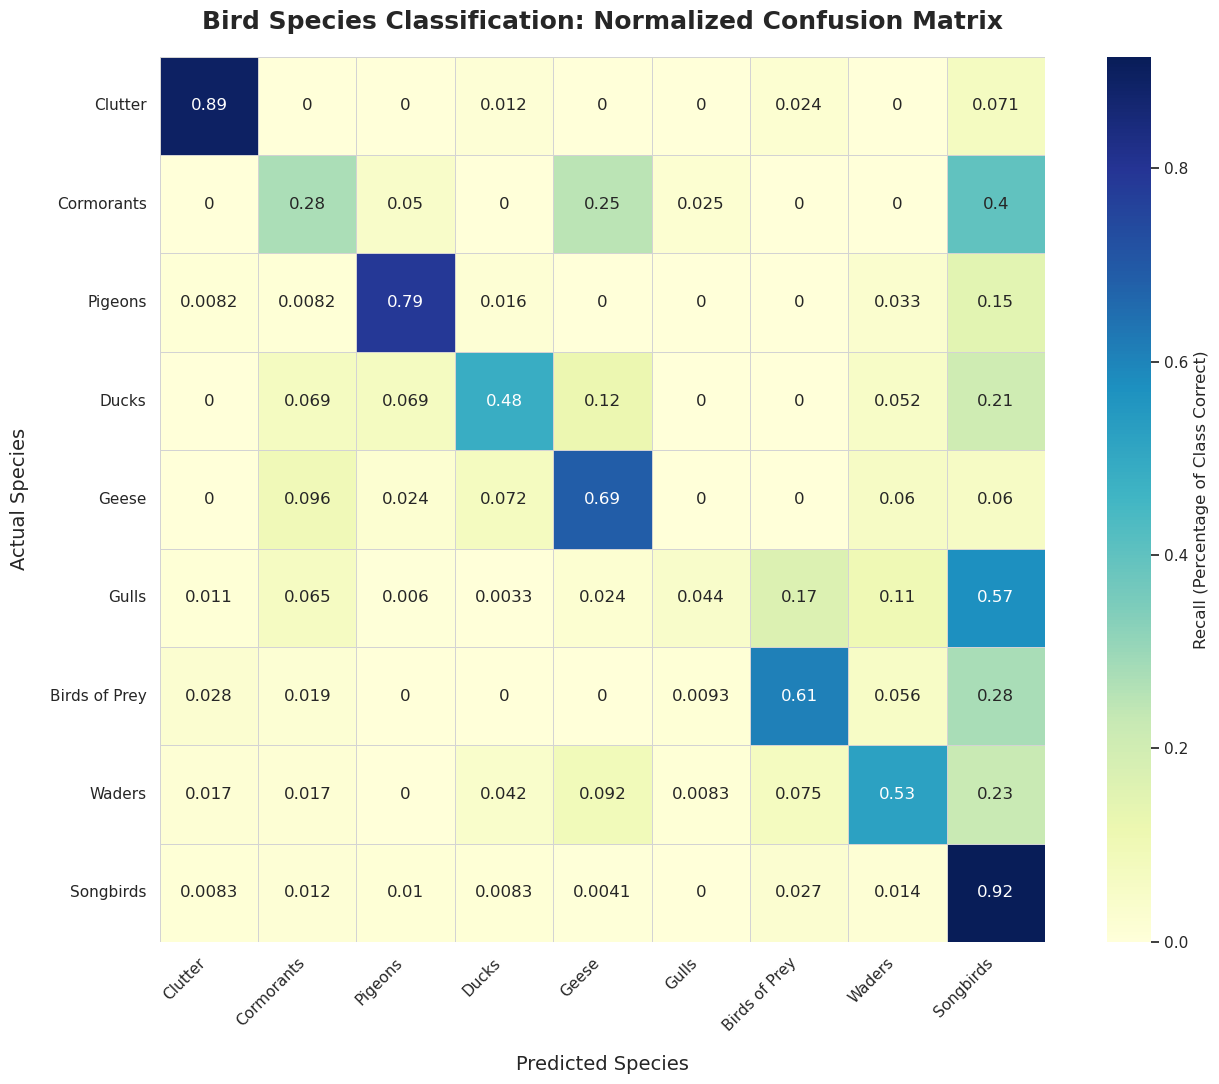

In [67]:
from result_analysis import plot_bird_confusion_pretty
plot_bird_confusion_pretty(y ,oof_preds)

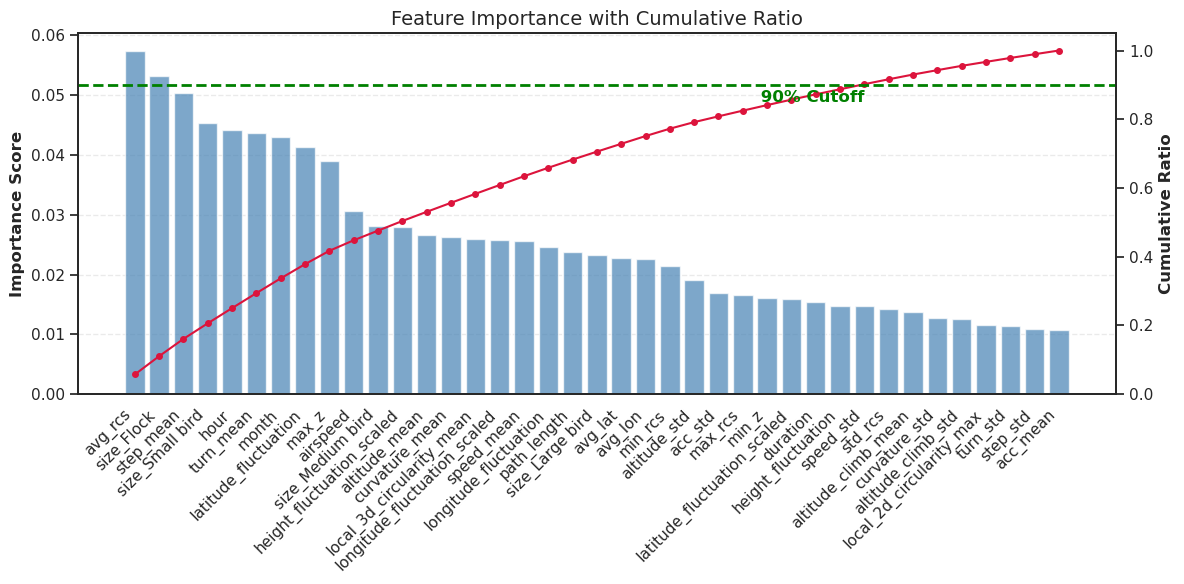

In [61]:
from result_analysis import plot_cumulative_importance
plot_cumulative_importance(models, features)

# Grid Search

In [62]:
sweep_config = {
    'method': 'grid', 
    'metric': {'name': 'mean_macro_ap', 'goal': 'maximize'},
    'parameters': {
        'learning_rate': {'values': [0.03, 0.05, 0.1]},
        'max_depth': {'values': [4, 6, 8]},
        'n_estimators': {'values': [1000]},
        'use_weights': {'values': [True, False]}
    }
}

#sweep_id = wandb.sweep(sweep_config, project="AICup")

def sweep_train():
    with wandb.init() as run:
        current_params = wandb.config
        models, oof_preds = run_cv_training_xgboost(
            X, y, 
            class_names=CLASS_NAMES, 
            params=current_params
        )

        final_score, detailed_scores = calculate_macro_ap(y, oof_preds, CLASS_NAMES)

        wandb.log({
            "mean_macro_ap": final_score,
            "detailed_scores": detailed_scores
        })

#wandb.agent(sweep_id, function=sweep_train)